# 03 - Feature engineering and classical ML baselines

**Goal:** find which causal, degradation-aware feature groups actually help, then establish tuned classical baselines (Ridge, ElasticNet, Random Forest, XGBoost, LightGBM). Everything runs inside the protocol fixed in `02_target_and_validation`.

**How the experiments were run.** The experiments are long-running, so they are executed by a script and this notebook analyses the saved results:

```
python -m src.pipelines.classical_experiments --stage all
```

Everything is in `reports/experiments/classical/`. The four subsets run as parallel processes, one per subset with 4 threads each, and each writes its own files:
- `{stage}_results_FD00x.csv` and `{stage}_predictions_FD00x.csv.gz`, with one row per validation sample;
- `selected_models_FD00x.csv` and `importance_FD00x.csv`;
- `environment.json` and `run_log_*.txt`.

**Protocol (unchanged from notebook 02):**
- 5 engine-level folds per subset (seed 42).
- 10 truncated validation samples per engine, with true RUL at the cut uniform in [6, 150]; one prediction per sample, from its truncated history only.
- Preprocessing (condition normalisation, health-index regression, scaling) is fitted on training-fold engines only.
- Scoring is against the **uncapped** true RUL.
- **Every model and feature set is scored on exactly the same validation samples.**

**The official test set is not used anywhere in this notebook or in the experiments.**

In [1]:
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.components.data_transformation import DERIVED_SENSORS, FoldPreprocessor
from src.components.validation import make_cv_plan, paired_rmse_difference, summarise_cv
from src.data_schema import SUBSETS
from src.pipelines.classical_experiments import CAP_GRID, FULL_CONFIG, OUT_DIR, feature_sets, load_stage, select_columns
from src.utils import add_train_rul, read_cmapss_file, rul_metrics

EXP = PROJECT_ROOT / OUT_DIR
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "classical"
TAB_DIR = PROJECT_ROOT / "reports" / "tables" / "classical"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)
print(json.load(open(EXP / "environment.json")))

{'python': '3.13.7', 'argv': ['C:\\Users\\Mayank\\Aircravft_RUL\\src\\pipelines\\classical_experiments.py', '--stage', 'finalize', '--subsets', 'FD004'], 'seed': 42, 'confirm_seed': 2024, 'ablation_cap': 125, 'cap_grid': [100, 110, 120, 125, 130, 140, 150], 'full_config': "FeatureConfig(groups=('current', 'mean', 'std', 'minmax', 'slope', 'delta', 'baseline', 'expanding'), mean_windows=(5, 10, 20, 30), std_windows=(10, 30), slope_windows=(10, 20, 30), minmax_windows=(10, 30), delta_lags=(10,), momentum_long=30, smooth_window=5, baseline_cycles=10, sensors=('T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'W31', 'W32'), derived=True, normalize=True, health_index=True, hi_window=10, hi_cap=125, hi_crossfit_folds=5, include_cycle=True)", 'numpy': '2.5.3', 'pandas': '3.0.6', 'sklearn': '1.9.1', 'xgboost': '3.4.1', 'lightgbm': '4.7.0', 'n_jobs_per_model': '4'}


In [2]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
FD_COLORS = dict(zip(SUBSETS, ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]))
MODEL_ORDER = ["ridge", "elasticnet", "random_forest", "xgboost", "lightgbm"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "legend.frameon": False,
    "lines.linewidth": 1.5, "figure.dpi": 90,
})


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print("saved", (FIG_DIR / f"{name}.png").relative_to(PROJECT_ROOT))


def savetab(df, name, index=True):
    df.to_csv(TAB_DIR / f"{name}.csv", index=index)
    print("saved", (TAB_DIR / f"{name}.csv").relative_to(PROJECT_ROOT))


abl, abl_pred = load_stage("ablation"), load_stage("ablation", "predictions")
seed = load_stage("seed_noise")
tune, tune_pred = load_stage("tune"), load_stage("tune", "predictions")
fin, fin_pred = load_stage("finalize"), load_stage("finalize", "predictions")
sel = pd.concat([pd.read_csv(EXP / f"selected_models_{s}.csv") for s in SUBSETS], ignore_index=True)
imp = pd.concat([pd.read_csv(EXP / f"importance_{s}.csv") for s in SUBSETS], ignore_index=True)
print({k: len(v) for k, v in dict(abl=abl, abl_pred=abl_pred, tune=tune, tune_pred=tune_pred, sel=sel, fin=fin, imp=imp).items()})

{'abl': 232, 'abl_pred': 411220, 'tune': 280, 'tune_pred': 496300, 'sel': 20, 'fin': 60, 'imp': 2520}


## 0. Leakage verification

The full test suite (70 tests) runs first. It covers:
- target correctness;
- engine-disjoint folds;
- truncation;
- brute-force correctness of every feature group;
- prefix invariance of the full pipeline, normalised and raw;
- future-row tampering;
- training-only fitting of the condition statistics, health index and scaler;
- the health index specifically (`tests/test_health_index.py`): `transform` never reads labels; validation features are invariant to validation labels; and with cross-fitting, a training engine's health index is invariant to its own labels;
- a spy test proving that `cross_validate` never fits on validation engines.

The leakage tests were themselves validated by injecting look-ahead bugs. Each injected bug was caught:
- a centred rolling window;
- a forward-shifted delta;
- an expanding max computed over the whole trajectory;
- fitting on all engines;
- an in-sample (not cross-fitted) health index.

In [3]:
t0 = time.time()
res = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q", "-p", "no:cacheprovider"], cwd=PROJECT_ROOT,
                     capture_output=True, text=True)
print(res.stdout.strip().splitlines()[-1], f"({time.time() - t0:.0f}s)")
assert res.returncode == 0

70 passed in 125.09s (0:02:05) (127s)


Additional run-time guarantees inside `build_fold_data` (asserted for every fold of every experiment):
- the preprocessor's fitted engines are disjoint from the validation engines;
- validation features come from truncated samples whose rows after the cut do not exist;
- each prediction row sits exactly at its cut cycle.

## 1. Feature groups (all causal)

All sensor features are computed on **condition-normalised** values (train-fold statistics), except in the raw ablation. A short trailing mean `m` (5 cycles) is the smoothed signal used by the delta, baseline and expanding groups.

In [4]:
groups_doc = pd.DataFrame([
    ("current", "value at t", "-"),
    ("mean", "trailing mean", "5, 10, 20, 30"),
    ("std", "trailing std (noise / instability)", "10, 30"),
    ("minmax", "trailing min and max", "10, 30"),
    ("slope", "trailing least-squares slope vs cycle (local degradation rate)", "10, 20, 30"),
    ("delta", "m(t) − m(t−10); m(t) − trailing mean over 30 (momentum)", "lag 10, 5 vs 30"),
    ("baseline", "m(t) − mean of the engine's own first 10 cycles (engine-specific initial wear removed)", "10"),
    ("expanding", "running max / min of m up to t (degradation envelope, robust to noise dips)", "-"),
    ("derived sensors", "; ".join(f"{k} = {v.split(':')[0]}" for k, v in DERIVED_SENSORS.items()), "all groups"),
    ("health_index", "ridge map of 10-cycle means → min(RUL,125)/125, fitted on training-fold engines only; training rows use 5-fold cross-fitted values (an engine's HI never comes from its own labels); value, slopes (10, 30), running min/max", "-"),
    ("cycle", "cycle number (engine age)", "-"),
], columns=["group", "definition (uses cycles ≤ t only)", "windows"])
groups_doc

,group,definition (uses cycles ≤ t only),windows
0,current,value at t,-
1,mean,trailing mean,"5, 10, 20, 30"
2,std,trailing std (noise / instability),"10, 30"
3,minmax,trailing min and max,"10, 30"
4,slope,trailing least-squares slope vs cycle (local degradation...,"10, 20, 30"
5,delta,m(t) − m(t−10); m(t) − trailing mean over 30 (momentum),"lag 10, 5 vs 30"
6,baseline,m(t) − mean of the engine's own first 10 cycles (engine-...,10
7,expanding,"running max / min of m up to t (degradation envelope, ro...",-
8,derived sensors,Wf_est = phi * Ps30; dT_HPC = T30 - T24; Nc_over_Nf = Nc...,all groups
9,health_index,"ridge map of 10-cycle means → min(RUL,125)/125, fitted o...",-


In [5]:
meta = FoldPreprocessor(config=FULL_CONFIG).fit(add_train_rul(read_cmapss_file("FD001", "train"))).feature_meta_
fs = feature_sets()
fs_table = pd.DataFrame([{"feature set": k, "groups": "+".join(v["groups"]) + (" +HI" if v["hi"] else "") + (" +cycle" if v["cycle"] else ""),
                          "sensors": len(v["sensors"]), "raw": v["raw"], "n_features": len(select_columns(meta, v)) + (6 if v["raw"] else 0)}
                         for k, v in fs.items()])
savetab(fs_table, "feature_sets", index=False)
fs_table

saved reports\tables\classical\feature_sets.csv


,feature set,groups,sensors,raw,n_features
0,F1_current,current,17,False,17
1,F2_+mean,current+mean,17,False,85
2,F3_+std,current+mean+std,17,False,119
3,F4_+minmax,current+mean+std+minmax,17,False,187
4,F5_+slope,current+mean+std+minmax+slope,17,False,238
5,F6_+delta,current+mean+std+minmax+slope+delta,17,False,272
6,F7_+baseline,current+mean+std+minmax+slope+delta+baseline,17,False,289
7,F8_+expanding,current+mean+std+minmax+slope+delta+baseline+expanding,17,False,323
8,F9_+derived,current+mean+std+minmax+slope+delta+baseline+expanding,21,False,399
9,F10_+health_index (FULL),current+mean+std+minmax+slope+delta+baseline+expanding +HI,21,False,404


## 2. Feature-group ablations

A fixed, untuned LightGBM (400 trees, 31 leaves, learning rate 0.05) and a Ridge (α = 10) are used, with the cap at 125 (the protocol prior). Differences are judged with a **paired engine-level bootstrap** (2000 resamples) on the identical validation samples. A difference counts only if its 95% CI excludes 0.

In [6]:
def rmse_table(model):
    t = abl[abl.model == model].pivot(index="feature_set", columns="subset", values="rmse")
    t["mean"] = t.mean(axis=1)
    return t.loc[list(fs)].round(2)

abl_lgb, abl_ridge = rmse_table("lightgbm"), rmse_table("ridge")
savetab(abl_lgb, "ablation_rmse_lightgbm")
savetab(abl_ridge, "ablation_rmse_ridge")
pd.concat({"LightGBM": abl_lgb, "Ridge": abl_ridge}, axis=1)

saved reports\tables\classical\ablation_rmse_lightgbm.csv
saved reports\tables\classical\ablation_rmse_ridge.csv


LightGBM                              Ridge                            
subset                                   FD001  FD002  FD003  FD004   mean  FD001  FD002  FD003  FD004   mean
feature_set                                                                                                  
F1_current                               23.41  23.76  23.25  23.51  23.48  24.43  24.90  25.41  25.84  25.15
F2_+mean                                 19.26  20.35  20.48  21.46  20.39  19.40  20.37  21.60  23.04  21.10
F3_+std                                  19.51  20.51  20.02  21.36  20.35  19.21  20.37  21.09  22.64  20.83
F4_+minmax                               20.87  21.39  20.37  21.79  21.11  19.23  20.12  21.19  22.74  20.82
F5_+slope                                17.72  18.89  18.10  19.54  18.56  19.20  20.07  21.20  22.72  20.80
F6_+delta                                17.43  18.79  17.90  19.47  18.40  19.20  20.02  21.11  22.70  20.76
F7_+baseline                             16.35  17.23  17.10  18.44  17.28  18.95  19.09  21.04  21.17  20.06
F8_+expanding                            16.92  18.06  17.48  19.24  17.92  19.89  18.79  20.29  21.37  20.09
F9_+derived                              17.05  18.11  17.98  19.45  18.15  19.82  19.05  19.99  21.34  20.05
F10_+health_index (FULL)                 16.53  17.68  17.63  19.25  17.77  19.83  19.09  19.95  21.31  20.05
F11_+cycle                               15.22  15.82  15.57  17.05  15.92  19.79  18.99  19.64  20.81  19.81
LOGO_-current                            16.67  17.61  17.70  19.28  17.82  19.82  19.10  19.95  21.31  20.05
LOGO_-mean                               16.80  17.82  17.90  19.16  17.92  19.89  19.31  20.20  21.25  20.16
LOGO_-std                                16.88  17.68  17.79  19.24  17.90  20.05  19.23  20.05  21.27  20.15
LOGO_-minmax                             16.65  17.66  17.73  19.36  17.85  20.10  19.41  19.75  21.12  20.10
LOGO_-slope                              16.96  17.74  18.08  19.74  18.13  19.80  19.11  19.92  21.30  20.03
LOGO_-delta                              16.75  17.72  17.69  19.18  17.84  19.77  19.09  19.94  21.29  20.03
LOGO_-baseline                           17.30  18.16  18.35  19.61  18.36  19.19  18.88  19.86  21.14  19.77
LOGO_-expanding                          16.07  17.16  17.15  18.28  17.17  19.01  19.11  20.93  21.16  20.05
LOGO_-derived                            16.66  17.68  17.79  19.16  17.82  19.94  18.84  20.30  21.33  20.10
LOGO_-health_index                       17.05  18.11  17.98  19.45  18.15  19.82  19.05  19.99  21.34  20.05
RAW_FULL (no condition normalisation)    16.42  18.90  17.83  22.19  18.84  19.93  19.91  20.14  21.59  20.39
S_core5_only                             18.42  18.74  20.61  21.09  19.71  20.58  19.25  21.21  21.42  20.61
S_-fault_mode_sensors                    17.04  18.31  19.08  19.39  18.45  19.94  19.02  21.05  21.24  20.31
S_-weak_sensors                          17.07  18.17  18.07  19.29  18.15  20.14  19.30  19.72  21.19  20.09
S_-corrected_speeds                      17.07  18.29  18.11  19.65  18.28  19.46  19.05  20.20  21.28  20.00
R1_F11 -expanding                        14.26  14.96  14.65  15.93  14.95  19.06  18.96  20.14  20.94  19.78
R2_F7 +cycle (minimal)                   14.05  14.65  14.25  15.78  14.68  19.02  18.99  20.40  20.95  19.84
R3_R1 -health_index                      14.15  14.86  14.54  15.72  14.82  18.97  19.09  20.10  20.87  19.76

In [7]:
def paired(model, set_a, set_b, subset):
    pa = abl_pred[(abl_pred.model == model) & (abl_pred.feature_set == set_a) & (abl_pred.subset == subset)]
    pb = abl_pred[(abl_pred.model == model) & (abl_pred.feature_set == set_b) & (abl_pred.subset == subset)]
    return paired_rmse_difference(pa, pb)

FULL = "F10_+health_index (FULL)"
rows = []
names = list(fs)
for model in ["lightgbm", "ridge"]:
    for s in SUBSETS:
        # forward steps: each set vs the previous one
        fwd = [n for n in names if n.startswith("F")]
        for prev, cur in zip(fwd[:-1], fwd[1:]):
            rows.append({"model": model, "subset": s, "comparison": "forward", "set": cur, "vs": prev} | paired(model, prev, cur, s))
        for n in names:
            if n[0] == "R" and not n.startswith("RAW"):
                rows.append({"model": model, "subset": s, "comparison": "refinement vs F11", "set": n, "vs": "F11_+cycle"}
                            | paired(model, "F11_+cycle", n, s))
            if n.startswith(("LOGO", "RAW")):
                rows.append({"model": model, "subset": s, "comparison": "vs FULL", "set": n, "vs": FULL} | paired(model, FULL, n, s))
            if n.startswith("S_"):
                rows.append({"model": model, "subset": s, "comparison": "sensors vs FULL-without-HI", "set": n, "vs": "LOGO_-health_index"}
                            | paired(model, "LOGO_-health_index", n, s))
paired_tab = pd.DataFrame(rows)
savetab(paired_tab, "ablation_paired_bootstrap", index=False)

def fmt(r):
    star = "*" if r.significant else ""
    return f"{r.delta_rmse:+.2f}{star}"

paired_tab.assign(cell=paired_tab.apply(fmt, axis=1)).pivot_table(
    index=["model", "comparison", "set"], columns="subset", values="cell", aggfunc="first").loc[["lightgbm", "ridge"]]

saved reports\tables\classical\ablation_paired_bootstrap.csv


subset                                                                      FD001   FD002   FD003   FD004
model    comparison                 set                                                                  
lightgbm forward                    F10_+health_index (FULL)               -0.51*  -0.43*   -0.34   -0.20
                                    F11_+cycle                             -1.32*  -1.86*  -2.06*  -2.19*
                                    F2_+mean                               -4.15*  -3.41*  -2.77*  -2.05*
                                    F3_+std                                 +0.25   +0.16   -0.47   -0.09
                                    F4_+minmax                             +1.36*  +0.88*   +0.36  +0.43*
                                    F5_+slope                              -3.15*  -2.50*  -2.28*  -2.25*
                                    F6_+delta                               -0.29   -0.10   -0.20   -0.07
                                    F7_+baseline                            -1.08  -1.56*   -0.80  -1.03*
                                    F8_+expanding                           +0.57  +0.83*   +0.38  +0.80*
                                    F9_+derived                             +0.13   +0.05  +0.50*   +0.21
         refinement vs F11          R1_F11 -expanding                      -0.96*  -0.86*  -0.92*  -1.12*
                                    R2_F7 +cycle (minimal)                 -1.17*  -1.17*  -1.32*  -1.28*
                                    R3_R1 -health_index                    -1.07*  -0.97*  -1.03*  -1.33*
         sensors vs FULL-without-HI S_-corrected_speeds                     +0.02   +0.18   +0.13   +0.21
                                    S_-fault_mode_sensors                   -0.01   +0.20  +1.10*   -0.06
                                    S_-weak_sensors                         +0.02   +0.06   +0.09   -0.16
                                    S_core5_only                           +1.37*   +0.63  +2.63*  +1.64*
         vs FULL                    LOGO_-baseline                          +0.77  +0.48*  +0.71*   +0.37
                                    LOGO_-current                           +0.14   -0.07   +0.06   +0.04
                                    LOGO_-delta                             +0.22   +0.04   +0.06   -0.06
                                    LOGO_-derived                           +0.12   +0.00   +0.16   -0.08
                                    LOGO_-expanding                         -0.46  -0.52*   -0.48  -0.97*
                                    LOGO_-health_index                     +0.51*  +0.43*   +0.34   +0.20
                                    LOGO_-mean                              +0.27   +0.14   +0.26   -0.08
                                    LOGO_-minmax                            +0.11   -0.02   +0.10   +0.11
                                    LOGO_-slope                            +0.42*   +0.06  +0.44*  +0.49*
                                    LOGO_-std                              +0.35*   +0.00   +0.15   -0.01
                                    RAW_FULL (no condition normalisation)   -0.12  +1.22*   +0.20  +2.94*
ridge    forward                    F10_+health_index (FULL)                +0.01   +0.04   -0.03   -0.03
                                    F11_+cycle                              -0.04  -0.10*  -0.32*  -0.50*
                                    F2_+mean                               -5.04*  -4.53*  -3.82*  -2.80*
                                    F3_+std                                 -0.18   +0.01  -0.51*  -0.39*
                                    F4_+minmax                              +0.02  -0.26*   +0.10   +0.10
                                    F5_+slope                               -0.03  -0.05*   +0.02   -0.02
                                    F6_+delta                               -0.00  -0.04*   -0.09   -0.02
                                    F7_+baseline                            -0

saved reports\figures\classical\01_forward_ablation.png


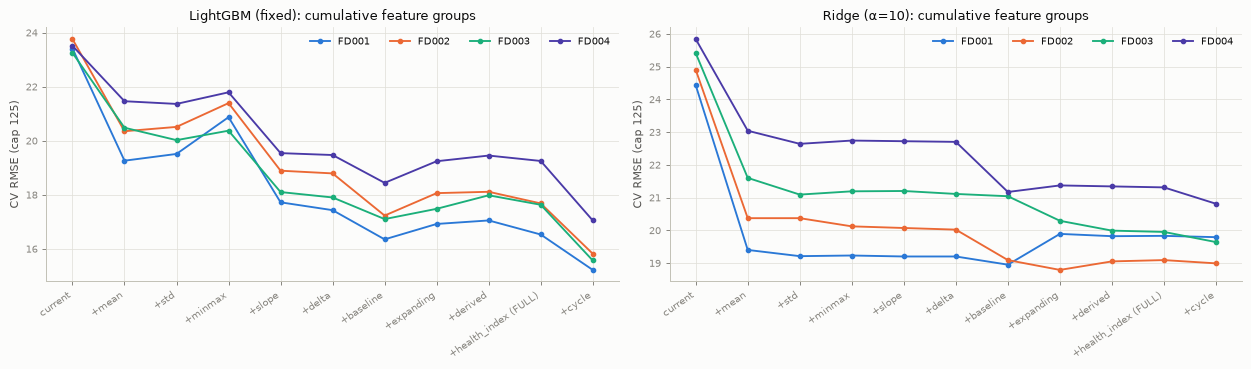

In [8]:
fwd = [n for n in names if n.startswith("F")]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
for ax, (model, tab) in zip(axes, [("LightGBM (fixed)", abl_lgb), ("Ridge (α=10)", abl_ridge)]):
    for s in SUBSETS:
        ax.plot(range(len(fwd)), tab.loc[fwd, s], marker="o", ms=3.5, color=FD_COLORS[s], label=s)
    ax.set_xticks(range(len(fwd)), [n.split("_", 1)[1] for n in fwd], rotation=35, ha="right")
    ax.set(title=f"{model}: cumulative feature groups", ylabel="CV RMSE (cap 125)")
    ax.legend(ncol=4)
fig.tight_layout()
savefig(fig, "01_forward_ablation")
plt.show()

saved reports\figures\classical\02_logo_ablation.png


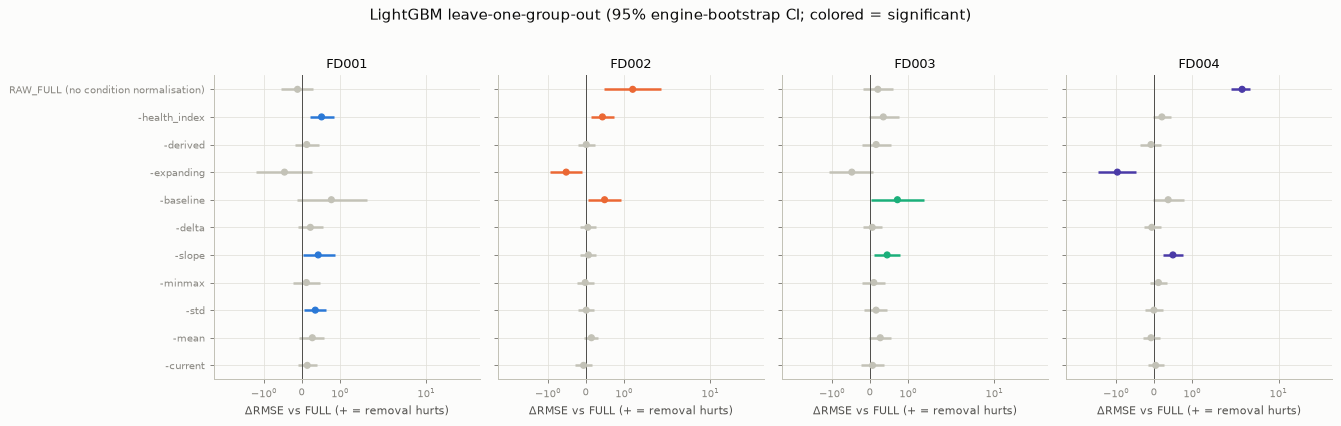

In [9]:
logo = [n for n in names if n.startswith(("LOGO", "RAW"))]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.6), sharey=True)
for ax, s in zip(axes, SUBSETS):
    t = paired_tab[(paired_tab.model == "lightgbm") & (paired_tab.subset == s) & (paired_tab.set.isin(logo))].set_index("set").loc[logo]
    y = np.arange(len(t))
    col = [FD_COLORS[s] if sig else AXIS for sig in t.significant]
    ax.hlines(y, t.ci_low, t.ci_high, color=col, lw=2)
    ax.scatter(t.delta_rmse, y, color=col, s=22, zorder=3)
    ax.axvline(0, color=INK2, lw=0.8)
    ax.set_yticks(y, [n.replace("LOGO_", "") for n in logo])
    ax.invert_yaxis()
    ax.set(title=s, xlabel="ΔRMSE vs FULL (+ = removal hurts)", xscale="symlog", xlim=(-3, 60))
fig.suptitle("LightGBM leave-one-group-out (95% engine-bootstrap CI; colored = significant)", y=1.02)
fig.tight_layout()
savefig(fig, "02_logo_ablation")
plt.show()

**Result (LightGBM; * = significant by engine bootstrap).**
- **Big, consistent gains:** trailing **mean** (−2.0 to −4.2), **slope** (−2.2 to −3.2), change from **baseline** (−0.8 to −1.6) and **cycle** (−1.3 to −2.2).
- **No gain or harmful:** std and delta add nothing. Rolling min/max (+0.4 to +1.4) and the **expanding** envelope (+0.4 to +0.8) *hurt* when added in the forward sequence; removing expanding from the full set improves RMSE in all four subsets (significant in FD002/FD004).
- **Derived sensors and health index:** derived sensors are neutral. The health index helps slightly without cycle (+0.2 to +0.5 when removed), and not at all once cycle is present (R3 ≈ R1).
- **Condition normalisation:** essential for multi-condition data, +1.2 (FD002) and +2.9 (FD004) RMSE without it. For single-condition data it is irrelevant to trees, as expected.
- **Sensors:** "core 5 only" is clearly worse (+0.6 to +2.6). Dropping the fault-mode sensors hurts only FD003 (+1.1*), which confirms the EDA hypothesis for that subset. Weak sensors and corrected-speed duplicates are neutral, since trees ignore them.
- **Ridge** gains much less from engineered features: it is limited by the non-linear RUL-sensor relationship, not by the features.

### 2.1 How large is model-seed noise?

LightGBM's row and column subsampling make its score depend on the random seed. The engine bootstrap above captures *sample* uncertainty but not this. The fixed ablation model was therefore re-run with 5 seeds on three candidate sets, using identical samples:

In [10]:
seed_tab = seed.groupby(["subset", "feature_set"]).rmse.agg(["mean", "std", "min", "max"]).round(2)
savetab(seed_tab, "seed_noise")
seed_tab.unstack("subset")

saved reports\tables\classical\seed_noise.csv


mean                        std                      min                         max                     
subset                  FD001  FD002  FD003  FD004 FD001 FD002 FD003 FD004  FD001  FD002  FD003  FD004  FD001  FD002  FD003  FD004
feature_set                                                                                                                       
F11_+cycle              15.17  15.77  15.81  17.11  0.10  0.09  0.23  0.08  15.08  15.66  15.54  16.98  15.35  15.88  16.14  17.20
R1_F11 -expanding       14.17  14.97  14.79  15.93  0.11  0.04  0.21  0.04  14.01  14.92  14.57  15.88  14.29  15.02  15.14  15.97
R2_F7 +cycle (minimal)  14.25  14.75  14.48  15.88  0.05  0.03  0.16  0.05  14.21  14.70  14.34  15.82  14.32  14.78  14.76  15.95

**Result.** Seed std is 0.03-0.23 RMSE (largest for FD003, with 100 engines). F11 → R1/R2 (removing expanding) is ≈1 RMSE, 5-10× the seed std, so it is real. R1 vs R2 vs R3 differ by ≤ 0.3, which is within seed noise. R2 is chosen by the rule and is also the simplest set.

## 3. Selected feature set

The rule was fixed before the ablations ran: **lowest mean LightGBM RMSE over the four subsets**. It is applied automatically by `choose_feature_set()`, and its choice is used by every model below.

**Disclosure: two-pass selection.** The first ablation run (archived in `reports/experiments/classical_v1_insample_hi/`) showed two things:
- the cycle feature gives a large gain;
- the expanding group hurts, while the rule-selected set still contained it.

Refinement sets R1-R3 were therefore added, and the ablation was re-run (also with the cross-fitted health index). Choosing among more candidates on the same folds adds a little selection bias. The independent confirmation plan (Section 4.1) measures it.

In [11]:
chosen_set = sel.feature_set.iloc[0]
print("selected feature set:", chosen_set)
print("n features:", int(tune.loc[tune.feature_set == chosen_set, "n_features"].iloc[0]))
abl_lgb.sort_values("mean").head(6)

selected feature set: R2_F7 +cycle (minimal)
n features: 290


subset,FD001,FD002,FD003,FD004,mean
feature_set,,,,,
R2_F7 +cycle (minimal),14.05,14.65,14.25,15.78,14.68
R3_R1 -health_index,14.15,14.86,14.54,15.72,14.82
R1_F11 -expanding,14.26,14.96,14.65,15.93,14.95
F11_+cycle,15.22,15.82,15.57,17.05,15.92
LOGO_-expanding,16.07,17.16,17.15,18.28,17.17
F7_+baseline,16.35,17.23,17.10,18.44,17.28


In [12]:
# Best feature set PER SUBSET (fixed LightGBM), with the seed-noise band of the leaders.
seed_mean = seed.groupby(["subset", "feature_set"]).rmse.agg(["mean", "std"])
per_subset = []
for s in SUBSETS:
    col = abl_lgb[s].sort_values()
    best = col.index[0]
    per_subset.append({"subset": s, "best set (single seed)": best, "RMSE": col.iloc[0],
                       "2nd": col.index[1], "RMSE 2nd": col.iloc[1],
                       "R2 RMSE (5-seed mean ± std)": f"{seed_mean.loc[(s, 'R2_F7 +cycle (minimal)'), 'mean']:.2f} ± {seed_mean.loc[(s, 'R2_F7 +cycle (minimal)'), 'std']:.2f}",
                       "R1 RMSE (5-seed mean ± std)": f"{seed_mean.loc[(s, 'R1_F11 -expanding'), 'mean']:.2f} ± {seed_mean.loc[(s, 'R1_F11 -expanding'), 'std']:.2f}",
                       "F11 RMSE (5-seed mean ± std)": f"{seed_mean.loc[(s, 'F11_+cycle'), 'mean']:.2f} ± {seed_mean.loc[(s, 'F11_+cycle'), 'std']:.2f}"})
per_subset = pd.DataFrame(per_subset).set_index("subset")
savetab(per_subset, "best_feature_set_per_subset")
per_subset

saved reports\tables\classical\best_feature_set_per_subset.csv


,best set (single seed),RMSE,2nd,RMSE 2nd,R2 RMSE (5-seed mean ± std),R1 RMSE (5-seed mean ± std),F11 RMSE (5-seed mean ± std)
subset,,,,,,,
FD001,R2_F7 +cycle (minimal),14.05,R3_R1 -health_index,14.15,14.25 ± 0.05,14.17 ± 0.11,15.17 ± 0.10
FD002,R2_F7 +cycle (minimal),14.65,R3_R1 -health_index,14.86,14.75 ± 0.03,14.97 ± 0.04,15.77 ± 0.09
FD003,R2_F7 +cycle (minimal),14.25,R3_R1 -health_index,14.54,14.48 ± 0.16,14.79 ± 0.21,15.81 ± 0.23
FD004,R3_R1 -health_index,15.72,R2_F7 +cycle (minimal),15.78,15.88 ± 0.05,15.93 ± 0.04,17.11 ± 0.08


## 4. Model tuning

Per subset and model family, tuning has two steps:
1. **Hyper-parameters** are searched at cap 125, with a fixed, seeded search space for each family (`src/components/model_trainer.py`):
   - Ridge: 5 alphas;
   - ElasticNet: 8 configs (alpha × l1_ratio; alpha ≥ 0.03, because smaller values do not converge on these collinear features);
   - Random Forest: 6 configs (min_samples_leaf × max_features; 200 trees, 30% row bootstrap);
   - XGBoost and LightGBM: 8 random configs each (LightGBM's include the ablation config). Learning rate is 0.05 or 0.1, with a fixed tree budget of 500 or 300. There is no early stopping, which would leak the validation folds into training.
2. **Cap** grid {100, 110, 120, 125, 130, 140, 150} for the best configuration.

The cap is chosen by the protocol rule: lowest RMSE, tie-broken to the largest cap within 1 SE.

In [13]:
hp = tune[tune.stage == "tune_hparams"]
hp_summary = hp.groupby(["subset", "model"]).agg(configs=("config_id", "nunique"), best_rmse=("rmse", "min"),
                                                 worst_rmse=("rmse", "max"), median_rmse=("rmse", "median")).round(2)
savetab(hp_summary, "hparam_search_summary")
hp_summary.unstack("subset")

saved reports\tables\classical\hparam_search_summary.csv


configs                   best_rmse                      worst_rmse                      median_rmse                     
subset          FD001 FD002 FD003 FD004     FD001  FD002  FD003  FD004      FD001  FD002  FD003  FD004       FD001  FD002  FD003  FD004
model                                                                                                                                  
elasticnet          8     8     8     8     18.96  19.01  20.27  20.88      20.14  20.13  21.44  22.25       19.34  19.26  20.49  21.20
lightgbm            8     8     8     8     14.05  14.65  14.25  15.74      14.56  14.97  14.62  16.07       14.30  14.76  14.52  15.84
random_forest       6     6     6     6     15.45  16.34  15.99  17.33      16.75  17.34  17.21  18.41       16.04  16.86  16.59  17.95
ridge               5     5     5     5     18.97  18.99  20.30  20.89      19.05  19.00  20.43  20.95       19.03  18.99  20.40  20.95
xgboost             8     8     8     8     13.95  14.51  14.32  15.97      14.79  15.07  14.93  16.27       14.16  14.75  14.69  16.14

saved reports\figures\classical\03_cap_per_model.png


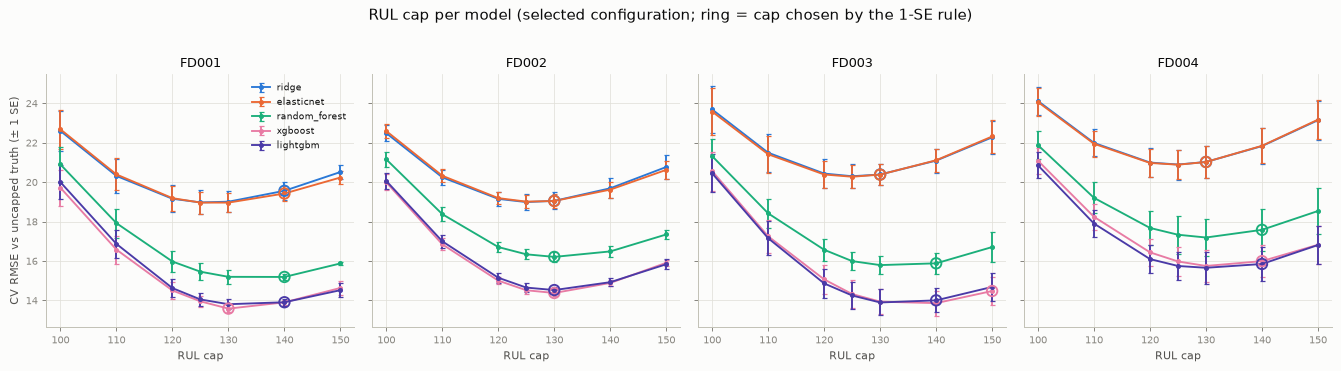

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
model_colors = dict(zip(MODEL_ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#e87ba4", "#4a3aa7"]))
capt = tune[tune.stage == "tune_cap"].merge(sel[["subset", "model", "config_id"]], on=["subset", "model", "config_id"])
for ax, s in zip(axes, SUBSETS):
    for m in MODEL_ORDER:
        c = capt[(capt.subset == s) & (capt.model == m)].sort_values("cap")
        ax.errorbar(c.cap, c.rmse, yerr=c.rmse_fold_std / np.sqrt(5), color=model_colors[m], marker="o", ms=3, capsize=2, label=m)
        chosen = sel[(sel.subset == s) & (sel.model == m)].cap.item()
        ax.scatter([chosen], c.loc[c.cap == chosen, "rmse"], s=70, facecolor="none", edgecolor=model_colors[m], lw=1.5, zorder=4)
    ax.set(title=s, xlabel="RUL cap")
axes[0].set_ylabel("CV RMSE vs uncapped truth (± 1 SE)")
axes[0].legend(fontsize=7)
fig.suptitle("RUL cap per model (selected configuration; ring = cap chosen by the 1-SE rule)", y=1.02)
fig.tight_layout()
savefig(fig, "03_cap_per_model")
plt.show()

In [15]:
prim = fin[fin.stage == "final_primary"].copy()
prim["fold RMSEs"] = prim.fold_rmse
cols = ["subset", "model", "cap", "rmse", "rmse_fold_std", "mae", "bias", "phm08_score_per_sample", "fold RMSEs"]
results_table = prim[cols].sort_values(["subset", "rmse"]).round(2)
savetab(results_table, "model_results_primary", index=False)
results_table

saved reports\tables\classical\model_results_primary.csv


,subset,model,cap,rmse,rmse_fold_std,mae,bias,phm08_score_per_sample,fold RMSEs
13,FD001,xgboost,130.0,13.58,0.43,10.13,-0.45,2.93,"[13.592, 14.026, 13.269, 13.955, 13.036]"
14,FD001,lightgbm,140.0,13.90,0.38,10.10,1.21,3.72,"[14.409, 13.464, 13.969, 14.068, 13.594]"
12,FD001,random_forest,140.0,15.19,0.36,11.38,1.79,4.33,"[14.729, 15.345, 15.221, 15.674, 14.956]"
11,FD001,elasticnet,140.0,19.42,0.89,16.06,4.83,6.98,"[19.14, 19.514, 18.877, 20.884, 18.614]"
10,FD001,ridge,140.0,19.56,0.99,16.06,4.43,7.16,"[19.049, 19.436, 19.736, 21.072, 18.405]"
28,FD002,xgboost,130.0,14.37,0.37,10.56,0.02,3.67,"[13.804, 14.654, 14.238, 14.709, 14.451]"
29,FD002,lightgbm,130.0,14.52,0.36,10.58,0.13,3.72,"[13.937, 14.629, 14.825, 14.448, 14.756]"
27,FD002,random_forest,130.0,16.21,0.52,12.15,0.56,5.07,"[15.325, 16.194, 16.699, 16.314, 16.463]"
26,FD002,elasticnet,130.0,19.04,0.80,15.35,2.50,6.70,"[18.343, 19.994, 18.242, 19.723, 18.84]"
25,FD002,ridge,130.0,19.05,0.96,15.34,2.30,6.78,"[18.278, 20.167, 17.884, 19.739, 19.079]"


In [16]:
best_params = sel[["subset", "model", "cap", "params"]].sort_values(["subset", "model"])
savetab(best_params, "selected_hyperparameters", index=False)
best_params

saved reports\tables\classical\selected_hyperparameters.csv


,subset,model,cap,params
1,FD001,elasticnet,140.0,"{""alpha"": 0.03, ""l1_ratio"": 0.2}"
4,FD001,lightgbm,140.0,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.05, ""min_ch..."
2,FD001,random_forest,140.0,"{""max_features"": 0.3, ""max_samples"": 0.3, ""min_samples_l..."
0,FD001,ridge,140.0,"{""alpha"": 100.0}"
3,FD001,xgboost,130.0,"{""colsample_bytree"": 0.3, ""learning_rate"": 0.05, ""max_de..."
6,FD002,elasticnet,130.0,"{""alpha"": 0.03, ""l1_ratio"": 0.2}"
9,FD002,lightgbm,130.0,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.05, ""min_ch..."
7,FD002,random_forest,130.0,"{""max_features"": 0.3, ""max_samples"": 0.3, ""min_samples_l..."
5,FD002,ridge,130.0,"{""alpha"": 0.1}"
8,FD002,xgboost,130.0,"{""colsample_bytree"": 0.5, ""learning_rate"": 0.05, ""max_de..."


### 4.1 Model comparison: paired tests and independent confirmation

Choosing the best of many configurations on the same folds biases the winner's score optimistically. Each subset's selected models are therefore re-scored on two further plans:
- an **independent confirmation plan** (new engine folds and new cuts, seed 2024), with no re-tuning;
- the **wide plan** (RUL up to 190).

In [17]:
piv = fin.pivot_table(index=["subset", "model"], columns="stage", values="rmse").round(2)
piv = piv[["final_primary", "final_confirm", "final_wide"]]
piv["confirm − primary"] = (piv.final_confirm - piv.final_primary).round(2)
savetab(piv, "model_results_all_plans")
piv

saved reports\tables\classical\model_results_all_plans.csv


stage                 final_primary  final_confirm  final_wide  confirm − primary
subset model                                                                     
FD001  elasticnet             19.42          19.44       25.88               0.02
       lightgbm               13.90          13.85       20.77              -0.05
       random_forest          15.19          14.84       22.15              -0.35
       ridge                  19.56          19.75       26.02               0.19
       xgboost                13.58          13.38       22.70              -0.20
FD002  elasticnet             19.04          19.24       27.30               0.20
       lightgbm               14.52          14.49       23.26              -0.03
       random_forest          16.21          16.36       24.58               0.15
       ridge                  19.05          19.23       27.19               0.18
       xgboost                14.37          14.22       23.11              -0.15
FD003  elasticnet             20.38          19.42       28.68              -0.96
       lightgbm               14.00          12.69       21.41              -1.31
       random_forest          15.88          14.54       22.74              -1.34
       ridge                  20.39          19.36       28.69              -1.03
       xgboost                14.47          13.39       19.51              -1.08
FD004  elasticnet             21.02          21.08       29.41               0.06
       lightgbm               15.85          16.17       22.71               0.32
       random_forest          17.58          17.85       24.33               0.27
       ridge                  21.02          21.11       29.42               0.09
       xgboost                15.99          16.00       22.83               0.01

In [18]:
cmp_rows = []
for s in SUBSETS:
    for stage in ["final_primary", "final_confirm"]:
        p = fin_pred[(fin_pred.subset == s) & (fin_pred.stage == stage)]
        r = fin[(fin.subset == s) & (fin.stage == stage)].sort_values("rmse")
        best = r.model.iloc[0]
        for m in r.model.iloc[1:]:
            cmp_rows.append({"subset": s, "plan": stage.replace("final_", ""), "best": best, "other": m}
                            | paired_rmse_difference(p[p.model == best], p[p.model == m]))
cmp = pd.DataFrame(cmp_rows).round(3)
savetab(cmp, "model_paired_comparison", index=False)
cmp

saved reports\tables\classical\model_paired_comparison.csv


,subset,plan,best,other,delta_rmse,ci_low,ci_high,significant
0,FD001,primary,xgboost,lightgbm,0.324,-0.240,0.877,False
1,FD001,primary,xgboost,random_forest,1.607,0.850,2.288,True
2,FD001,primary,xgboost,elasticnet,5.841,4.991,6.686,True
3,FD001,primary,xgboost,ridge,5.979,5.072,6.837,True
4,FD001,confirm,xgboost,lightgbm,0.470,-0.105,1.013,False
5,FD001,confirm,xgboost,random_forest,1.456,0.696,2.171,True
6,FD001,confirm,xgboost,elasticnet,6.062,5.160,7.020,True
7,FD001,confirm,xgboost,ridge,6.369,5.356,7.472,True
8,FD002,primary,xgboost,lightgbm,0.148,-0.031,0.331,False
9,FD002,primary,xgboost,random_forest,1.831,1.437,2.237,True


In [19]:
mean_rank = fin[fin.stage.isin(["final_primary", "final_confirm"])].assign(
    rank=lambda d: d.groupby(["stage", "subset"]).rmse.rank()).groupby("model")["rank"].mean().sort_values()
overall = pd.DataFrame({
    "mean RMSE primary": prim.groupby("model").rmse.mean(),
    "mean RMSE confirm": fin[fin.stage == "final_confirm"].groupby("model").rmse.mean(),
    "mean RMSE wide": fin[fin.stage == "final_wide"].groupby("model").rmse.mean(),
    "mean PHM08/sample primary": prim.groupby("model").phm08_score_per_sample.mean(),
    "mean rank (primary+confirm, 8 cases)": mean_rank,
}).round(2).sort_values("mean RMSE primary")
savetab(overall, "model_overall")
overall

saved reports\tables\classical\model_overall.csv


,mean RMSE primary,mean RMSE confirm,mean RMSE wide,mean PHM08/sample primary,"mean rank (primary+confirm, 8 cases)"
model,,,,,
lightgbm,14.57,14.30,22.04,4.29,1.62
xgboost,14.61,14.25,22.04,4.41,1.38
random_forest,16.21,15.90,23.45,5.51,3.00
elasticnet,19.97,19.80,27.82,8.12,4.25
ridge,20.00,19.86,27.83,8.17,4.75


saved reports\figures\classical\04_model_comparison.png


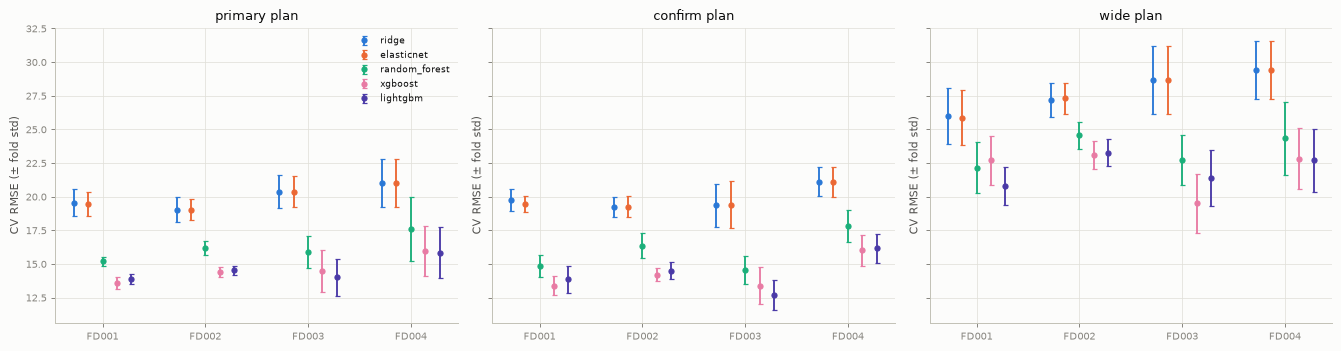

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, stage in zip(axes, ["final_primary", "final_confirm", "final_wide"]):
    d = fin[fin.stage == stage]
    x = np.arange(len(SUBSETS))
    for i, m in enumerate(MODEL_ORDER):
        r = d[d.model == m].set_index("subset").loc[SUBSETS]
        ax.errorbar(x + (i - 2) * 0.14, r.rmse, yerr=r.rmse_fold_std, fmt="o", ms=4, capsize=2, color=model_colors[m], label=m)
    ax.set_xticks(x, SUBSETS)
    ax.set(title=stage.replace("final_", "") + " plan", ylabel="CV RMSE (± fold std)")
axes[0].legend(fontsize=7)
fig.tight_layout()
savefig(fig, "04_model_comparison")
plt.show()

**Result.**
- **Boosted trees win clearly.** XGBoost and LightGBM are statistically tied in every subset on the primary plan, with paired CIs including 0. Both beat Random Forest by 1.5-1.9 RMSE and the linear models by 4.7-6.4 RMSE (all significant).
- **Selection bias is negligible.** On the independent confirmation plan, FD001/FD002/FD004 move by ≤ 0.35. FD003 improves by ≈1.0-1.3 for *every* model, including untuned Ridge, so that is plan variance from the small subset, not selection bias.
- **The wide plan (RUL ≤ 190) costs 6-9 RMSE**, as expected from caps of 130-150.

## 5. Feature importance

**Permutation importance** on the validation samples: the increase in RMSE when a whole feature group, or all features of one sensor, are permuted together across samples (3 repeats, averaged over the 5 folds). Permuting blocks avoids the dilution that correlated features cause in single-feature importances. **Native gain** importance of the boosted trees is shown for the top individual features.

In [21]:
best_by_subset = prim.sort_values("rmse").groupby("subset").model.first()
print(best_by_subset.to_dict())
pi = imp[imp.kind.isin(["group", "sensor"])]
pi_tab = pi.groupby(["model", "subset", "kind", "unit"]).rmse_increase.mean().unstack("subset").round(2)
savetab(pi_tab, "permutation_importance")
model_for_imp = "lightgbm"
for kind in ["group", "sensor"]:
    display(pi_tab.loc[(model_for_imp, kind)].assign(mean=lambda d: d.mean(axis=1)).sort_values("mean", ascending=False).round(2))

{'FD001': 'xgboost', 'FD002': 'xgboost', 'FD003': 'lightgbm', 'FD004': 'lightgbm'}
saved reports\tables\classical\permutation_importance.csv


subset,FD001,FD002,FD003,FD004,mean
unit,,,,,
baseline,28.77,31.50,27.70,30.45,29.60
cycle,5.05,6.17,6.55,7.03,6.20
mean,5.87,7.04,4.00,4.44,5.34
slope,1.38,0.58,3.16,1.58,1.68
minmax,0.43,1.34,2.29,2.24,1.58
delta,0.39,0.62,0.34,0.73,0.52
std,0.19,-0.02,0.29,0.17,0.16
current,0.00,0.00,0.00,0.00,0.00


subset,FD001,FD002,FD003,FD004,mean
unit,,,,,
Ps30,4.42,9.43,6.46,12.38,8.17
cycle,5.18,6.24,6.70,6.83,6.24
T50,2.48,3.41,4.08,2.67,3.16
NRc,2.13,1.51,1.54,0.86,1.51
Nc,1.62,0.77,2.03,1.32,1.44
BPR,0.95,3.11,0.39,0.59,1.26
phi,0.61,0.06,1.29,0.26,0.55
htBleed,0.21,0.43,0.82,0.68,0.54
T24,0.33,0.79,0.06,0.34,0.38


saved reports\figures\classical\05_permutation_importance.png


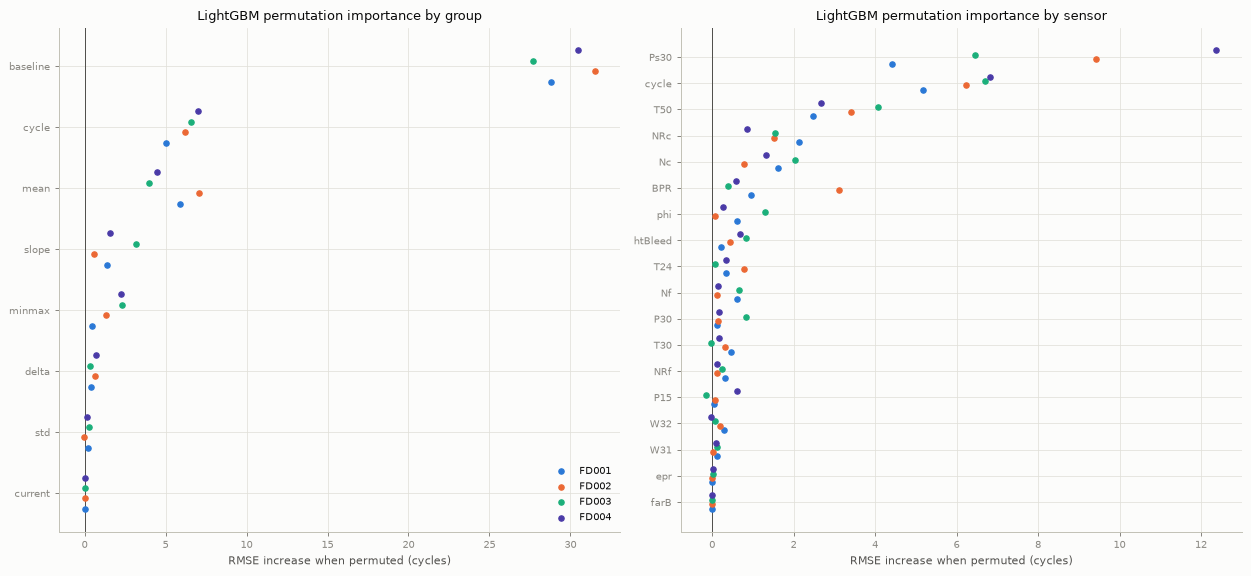

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, kind in zip(axes, ["group", "sensor"]):
    t = pi_tab.loc[(model_for_imp, kind)]
    order = t.mean(axis=1).sort_values().index
    y = np.arange(len(order))
    for i, s in enumerate(SUBSETS):
        ax.scatter(t.loc[order, s], y + (i - 1.5) * 0.17, color=FD_COLORS[s], s=18, label=s, zorder=3)
    ax.set_yticks(y, order)
    ax.axvline(0, color=INK2, lw=0.8)
    ax.set(title=f"LightGBM permutation importance by {kind}", xlabel="RMSE increase when permuted (cycles)")
axes[0].legend()
fig.tight_layout()
savefig(fig, "05_permutation_importance")
plt.show()

In [23]:
native = imp[(imp.kind == "feature_native") & (imp.model == "lightgbm")]
top = native.groupby(["unit", "subset"]).rmse_increase.mean().unstack()
top["mean"] = top.mean(axis=1)
top = top.sort_values("mean", ascending=False).head(20).round(4)
top.columns.name = "share of split gain"
savetab(top, "top20_features_lightgbm_gain")
top

saved reports\tables\classical\top20_features_lightgbm_gain.csv


share of split gain,FD001,FD002,FD003,FD004,mean
unit,,,,,
cycle_feature,0.0512,0.0682,0.0554,0.0564,0.0578
Ps30_delta_base,0.0163,0.0257,0.0156,0.0173,0.0187
NRc_delta_base,0.0134,0.0172,0.0164,0.0121,0.0148
W32_min30,0.0146,0.0145,0.0104,0.0187,0.0146
T50_delta_base,0.0108,0.0158,0.0152,0.0116,0.0134
T24_max30,0.0114,0.0150,0.0112,0.0140,0.0129
T24_min30,0.0112,0.0144,0.0100,0.0157,0.0128
T30_min30,0.0116,0.0130,0.0118,0.0146,0.0128
T30_max30,0.0143,0.0105,0.0099,0.0160,0.0127


**Result.**
- **Groups:** permuting the **baseline** group (change from the engine's own early life) raises RMSE by ≈30 cycles. It is by far the most relied-on group, followed by cycle (≈6), mean (≈5), slope (≈1.7) and min/max (≈1.6).
- **Sensors:** **Ps30** (≈8) and **cycle** (≈6) lead, then T50, Nc/NRc and BPR (strongest in FD002). epr and farB are unused.
- **Gain vs permutation:** split gain spreads over min/max and mean features (≈35% and ≈15%) even though removing min/max costs nothing. They are heavily used but substitutable, which is why gain alone is misleading here.

## 6. Error analysis (best model per subset, primary plan)

In [24]:
fp = fin_pred[fin_pred.stage == "final_primary"]
bestp = pd.concat([fp[(fp.subset == s) & (fp.model == m)] for s, m in best_by_subset.items()])
bestp = bestp.assign(err=bestp.y_pred - bestp.y_true,
                     band=pd.cut(bestp.y_true, [0, 25, 50, 75, 100, 125, 150], labels=["6-25", "26-50", "51-75", "76-100", "101-125", "126-150"]),
                     hist=pd.cut(bestp.cut_cycle, [0, 30, 60, 100, 150, 600], labels=["≤30", "31-60", "61-100", "101-150", ">150"]))
by_band = bestp.groupby(["subset", "band"], observed=True).apply(
    lambda g: pd.Series({"n": len(g), "rmse": np.sqrt(np.mean(g.err ** 2)), "bias": g.err.mean(),
                         "late (>+10)": np.mean(g.err > 10)})).round(2)
savetab(by_band, "errors_by_true_rul")
by_band.unstack("subset")

saved reports\tables\classical\errors_by_true_rul.csv


n                        rmse                        bias                      late (>+10)                  
subset   FD001  FD002  FD003  FD004  FD001  FD002  FD003  FD004  FD001  FD002  FD003  FD004       FD001 FD002 FD003 FD004
band                                                                                                                     
6-25     118.0  344.0  117.0  332.0   4.39   3.94   2.79   6.52   0.79   0.28   0.48   2.48        0.04  0.02  0.00  0.11
26-50    194.0  467.0  193.0  440.0   7.01   8.70   7.72  10.15   1.94   2.97   3.03   4.26        0.12  0.15  0.13  0.19
51-75    180.0  449.0  181.0  426.0  12.63  15.05  13.77  18.32   5.28   7.03   6.08   7.41        0.31  0.35  0.29  0.38
76-100   170.0  448.0  167.0  438.0  16.15  16.89  16.96  20.50   6.91   8.12   6.75   8.51        0.39  0.41  0.39  0.46
101-125  160.0  447.0  161.0  421.0  13.01  12.77  15.07  15.84   0.58  -1.08   0.00   2.14        0.22  0.22  0.26  0.36
126-150  178.0  445.0  181.0  433.0  20.19  20.89  18.91  17.53 -17.61 -17.40 -11.88 -12.04        0.00  0.00  0.04  0.03

In [25]:
by_hist = bestp.groupby(["subset", "hist"], observed=True).apply(
    lambda g: pd.Series({"n": len(g), "rmse": np.sqrt(np.mean(g.err ** 2)), "bias": g.err.mean(),
                         "mean true RUL": g.y_true.mean()})).round(2)
savetab(by_hist, "errors_by_history_length")
by_hist.unstack("subset")

saved reports\tables\classical\errors_by_history_length.csv


n                         rmse                       bias                   mean true RUL                        
subset   FD001  FD002  FD003   FD004  FD001  FD002  FD003  FD004 FD001 FD002 FD003 FD004         FD001   FD002   FD003   FD004
hist                                                                                                                          
≤30       32.0  117.0   26.0    61.0  13.73  13.09   8.48  14.29 -7.40 -5.94 -2.33 -0.77        135.53  134.50  139.27  134.90
31-60    124.0  255.0   54.0   161.0  18.13  18.76  14.30  18.44 -1.58  0.01  2.36  3.87        124.08  123.53  127.61  124.97
61-100   193.0  548.0  144.0   332.0  18.41  19.95  20.01  21.70  2.99  2.41  6.18  8.75        101.55  104.09  110.58  105.90
101-150  289.0  780.0  265.0   591.0  11.53  13.36  16.30  17.17  0.60  1.35  2.53  4.08         71.46   70.68   75.98   80.40
>150     362.0  900.0  511.0  1345.0   9.67   8.83  10.38  13.00 -2.11 -1.81 -1.77 -0.46         49.30   47.50   61.80   61.76

saved reports\figures\classical\06_error_analysis.png


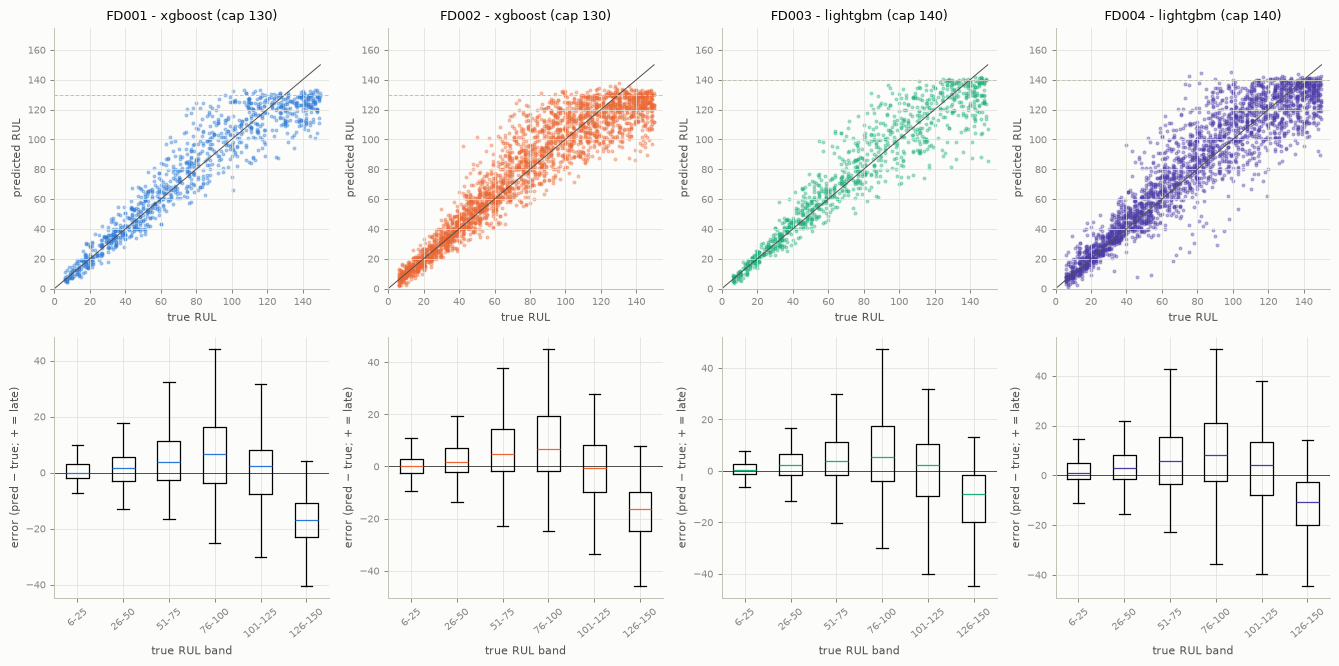

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
for j, s in enumerate(SUBSETS):
    d = bestp[bestp.subset == s]
    axes[0, j].scatter(d.y_true, d.y_pred, s=5, alpha=0.35, color=FD_COLORS[s])
    axes[0, j].plot([0, 150], [0, 150], color=INK2, lw=0.8)
    cap = sel[(sel.subset == s) & (sel.model == best_by_subset[s])].cap.item()
    axes[0, j].axhline(cap, color=AXIS, lw=0.8, ls="--")
    axes[0, j].set(title=f"{s} - {best_by_subset[s]} (cap {cap:g})", xlabel="true RUL", ylabel="predicted RUL", xlim=(0, 155), ylim=(0, 175))
    g = d.groupby("band", observed=True).err
    axes[1, j].axhline(0, color=INK2, lw=0.8)
    axes[1, j].boxplot([v.to_numpy() for _, v in g], tick_labels=[str(k) for k in g.groups.keys()], showfliers=False,
                       medianprops=dict(color=FD_COLORS[s]))
    axes[1, j].set(xlabel="true RUL band", ylabel="error (pred − true; + = late)")
    axes[1, j].tick_params(axis="x", rotation=40)
fig.tight_layout()
savefig(fig, "06_error_analysis")
plt.show()

In [27]:
# FD003/FD004 fault-mode groups (EDA 10.5): sign of each validation engine's end-of-life phi change.
# Uses the engine's FULL training trajectory -> analysis only, never a feature.
from src.components.data_transformation import ConditionNormalizer

mode_rows = []
for s in ["FD003", "FD004"]:
    tr = add_train_rul(read_cmapss_file(s, "train"))
    z = ConditionNormalizer().fit(tr).transform(tr).sort_values(["unit_id", "cycle"])
    dphi = z.groupby("unit_id").phi.apply(lambda x: x.tail(20).mean() - x.head(20).mean())
    d = bestp[bestp.subset == s].assign(mode=lambda d: np.where(d.unit_id.map(dphi) > 0, "phi rises (2nd mode)", "phi falls (HPC-like)"))
    for mode, g in d.groupby("mode"):
        mode_rows.append({"subset": s, "group": mode, "engines": g.unit_id.nunique()} | {k: round(v, 2) for k, v in rul_metrics(g.y_true, g.y_pred).items() if k != "n"})
fault_mode_err = pd.DataFrame(mode_rows)
savetab(fault_mode_err, "errors_by_fault_mode", index=False)
fault_mode_err

saved reports\tables\classical\errors_by_fault_mode.csv


,subset,group,engines,rmse,mae,bias,phm08_score,phm08_score_per_sample
0,FD003,phi falls (HPC-like),56,15.52,10.97,0.29,2382.75,4.25
1,FD003,phi rises (2nd mode),44,11.80,8.61,1.27,1172.01,2.66
2,FD004,phi falls (HPC-like),148,15.50,11.41,1.41,7849.31,5.30
3,FD004,phi rises (2nd mode),101,16.34,11.70,3.16,7530.66,7.46


In [28]:
worst = bestp.groupby(["subset", "unit_id"]).apply(lambda g: pd.Series({
    "rmse": np.sqrt(np.mean(g.err ** 2)), "bias": g.err.mean(), "lifespan": g.lifespan.iloc[0]})).reset_index()
life_q = worst.groupby("subset").lifespan.transform(lambda v: v.rank(pct=True))
worst["lifespan percentile"] = life_q.round(2)
worst_tab = worst.sort_values("rmse", ascending=False).groupby("subset").head(5).round(1)
savetab(worst_tab, "worst_engines", index=False)
print("Correlation of per-engine bias with lifespan:",
      worst.groupby("subset").apply(lambda g: round(np.corrcoef(g.lifespan, g.bias)[0, 1], 2)).to_dict())
worst_tab

saved reports\tables\classical\worst_engines.csv
Correlation of per-engine bias with lifespan: {'FD001': -0.75, 'FD002': -0.67, 'FD003': -0.43, 'FD004': -0.5}


,subset,unit_id,rmse,bias,lifespan,lifespan percentile
524,FD004,65,41.8,-41.5,351.0,0.9
644,FD004,185,41.6,-24.0,259.0,0.6
573,FD004,114,41.5,38.2,161.0,0.1
365,FD003,6,36.6,-31.8,278.0,0.8
643,FD004,184,35.9,-19.4,379.0,1.0
530,FD004,71,35.7,27.5,312.0,0.8
351,FD002,252,34.5,24.2,135.0,0.0
445,FD003,86,33.7,-32.9,341.0,0.9
100,FD002,1,30.8,24.3,149.0,0.1
211,FD002,112,29.2,-26.6,378.0,1.0


### 6.1 Is the lifespan-dependent bias caused by the cycle feature?

Same fixed LightGBM, same validation samples, with and without `cycle` (ablation sets F7 vs R2). For each, the table shows:
- the per-engine mean error (bias) for short-, mid- and long-lived engines;
- the correlation of that bias with lifespan.

In [29]:
rows = []
for s in SUBSETS:
    for name, fset in [("without cycle (F7)", "F7_+baseline"), ("with cycle (R2)", "R2_F7 +cycle (minimal)")]:
        p = abl_pred[(abl_pred.model == "lightgbm") & (abl_pred.subset == s) & (abl_pred.feature_set == fset)]
        e = p.assign(err=p.y_pred - p.y_true).groupby("unit_id").agg(bias=("err", "mean"), lifespan=("lifespan", "first"))
        tercile = pd.qcut(e.lifespan, 3, labels=["short-lived", "mid", "long-lived"])
        rows.append({"subset": s, "features": name, "rmse": np.sqrt(np.mean((p.y_pred - p.y_true) ** 2)),
                     "corr(bias, lifespan)": np.corrcoef(e.bias, e.lifespan)[0, 1]}
                    | e.groupby(tercile, observed=True).bias.mean().add_prefix("bias ").to_dict())
cycle_bias = pd.DataFrame(rows).round(2)
savetab(cycle_bias, "cycle_feature_lifespan_bias", index=False)
cycle_bias

saved reports\tables\classical\cycle_feature_lifespan_bias.csv


,subset,features,rmse,"corr(bias, lifespan)",bias short-lived,bias mid,bias long-lived
0,FD001,without cycle (F7),16.35,-0.85,5.84,-0.68,-11.33
1,FD001,with cycle (R2),14.05,-0.73,4.28,-2.42,-7.72
2,FD002,without cycle (F7),17.23,-0.84,9.12,-0.09,-12.09
3,FD002,with cycle (R2),14.65,-0.65,6.42,-2.92,-7.09
4,FD003,without cycle (F7),17.10,-0.52,6.00,-0.17,-11.55
5,FD003,with cycle (R2),14.25,-0.43,3.80,-2.57,-7.93
6,FD004,without cycle (F7),18.44,-0.61,8.06,-1.22,-9.28
7,FD004,with cycle (R2),15.78,-0.46,4.53,-2.28,-5.72


In [30]:
# Does the lifespan-dependent bias remain for the FINAL selected models? (primary + confirmation plans)
rows = []
for stage in ["final_primary", "final_confirm"]:
    for s, m in best_by_subset.items():
        p = fin_pred[(fin_pred.stage == stage) & (fin_pred.subset == s) & (fin_pred.model == m)]
        e = p.assign(err=p.y_pred - p.y_true).groupby("unit_id").agg(bias=("err", "mean"), lifespan=("lifespan", "first"))
        tercile = pd.qcut(e.lifespan, 3, labels=["short-lived", "mid", "long-lived"])
        rows.append({"plan": stage.replace("final_", ""), "subset": s, "model": m,
                     "corr(bias, lifespan)": np.corrcoef(e.bias, e.lifespan)[0, 1]}
                    | e.groupby(tercile, observed=True).bias.mean().add_prefix("bias ").to_dict()
                    | {"share of short-lived engines predicted late (bias > +10)": float((e.bias[tercile == "short-lived"] > 10).mean())})
final_bias = pd.DataFrame(rows).round(2)
savetab(final_bias, "final_model_lifespan_bias", index=False)
final_bias

saved reports\tables\classical\final_model_lifespan_bias.csv


,plan,subset,model,"corr(bias, lifespan)",bias short-lived,bias mid,bias long-lived,share of short-lived engines predicted late (bias > +10)
0,primary,FD001,xgboost,-0.75,5.43,-0.75,-6.76,0.28
1,primary,FD002,xgboost,-0.67,7.71,-1.57,-6.63,0.34
2,primary,FD003,lightgbm,-0.43,7.38,0.19,-5.80,0.38
3,primary,FD004,lightgbm,-0.50,8.93,0.99,-3.57,0.46
4,confirm,FD001,xgboost,-0.78,6.51,-1.08,-6.58,0.28
5,confirm,FD002,xgboost,-0.67,7.74,-1.71,-6.79,0.37
6,confirm,FD003,lightgbm,-0.50,7.18,1.27,-5.23,0.35
7,confirm,FD004,lightgbm,-0.52,10.24,1.13,-3.61,0.47


**Result.**
- **By true RUL:** accurate near failure (RMSE 3-7 for RUL ≤ 25). Largest errors and a **late bias** (+5 to +8.5 cycles, 31-46% of samples > 10 cycles late) at true RUL 51-100. Strong early bias (−12 to −18) at 126-150, where predictions saturate at the cap.
- **By history length:** very short histories (≤ 30 cycles) are slightly under-predicted. Mid-length histories (61-100 cycles) have the highest RMSE.
- **By fault mode:** in FD003 the second mode is *easier* (11.8 vs 15.5). In FD004 it is slightly worse and more late-biased (bias +3.2, PHM08 7.5 vs 5.3).
- **Lifespan-dependent bias:** this is **not caused by the cycle feature**. It is stronger without cycle (corr −0.52 to −0.85 → −0.43 to −0.73 with it). It **remains in the final models** (corr −0.43 to −0.78 on both plans). Short-lived (fast-degrading) engines are over-predicted by +5 to +10 cycles, and 28-47% of them have mean error > +10, i.e. dangerously late. The worst engines are all lifespan extremes.

## 6.2 Official test set: static verification that it was never used

The experiment code may only read training files. The check below scans the experiment pipeline, the model registry and this notebook for any access to test trajectories or RUL files.

In [31]:
import re as _re
checked = {
    "src/pipelines/classical_experiments.py": None, "src/components/model_trainer.py": None,
    "src/components/validation.py": None, "src/components/data_transformation.py": None,
}
pat = _re.compile(r"read_rul_file|add_test_rul|\"test\"|'test'|test_FD|RUL_FD")
for f in checked:
    src = (PROJECT_ROOT / f).read_text(encoding="utf-8")
    checked[f] = [ln.strip() for ln in src.splitlines() if pat.search(ln) and not ln.strip().startswith("#")]
nb_src = (PROJECT_ROOT / "notebooks" / "03_features_and_classical_ml.ipynb").read_text(encoding="utf-8")
calls = _re.findall(r"read_cmapss_file\(([^)]*)\)", (PROJECT_ROOT / "src/pipelines/classical_experiments.py").read_text(encoding="utf-8"))
print("read_cmapss_file calls in the experiment pipeline:", calls)
for f, hits in checked.items():
    print(f"{f}: {hits if hits else 'no test/RUL-file access'}")
print("this notebook reads test/RUL files:", bool(_re.search(r"read_rul_file\(|add_test_rul\(|read_cmapss_file\([^)]*test", nb_src)))

read_cmapss_file calls in the experiment pipeline: ['subset, "train", RAW_DIR']
src/pipelines/classical_experiments.py: no test/RUL-file access
src/components/model_trainer.py: no test/RUL-file access
src/components/validation.py: ['(lifespan - cut_cycle), the same definition as RUL_FD00x.txt.']
src/components/data_transformation.py: no test/RUL-file access
this notebook reads test/RUL files: False


## 7. Summary

Full stage report: `reports/classical_ml_stage_report.md`.